Race (Black vs Caucasian) → AIR: 2.086 | ME: 0.270 | SMD: 0.577
Sex (Female vs Male) → AIR: 0.324 | ME: -0.295 | SMD: -0.689

Worst-group (intersectional) AIR: 0.794
African-American: FPR = 0.312 | FNR = 0.297
Caucasian: FPR = 0.162 | FNR = 0.609


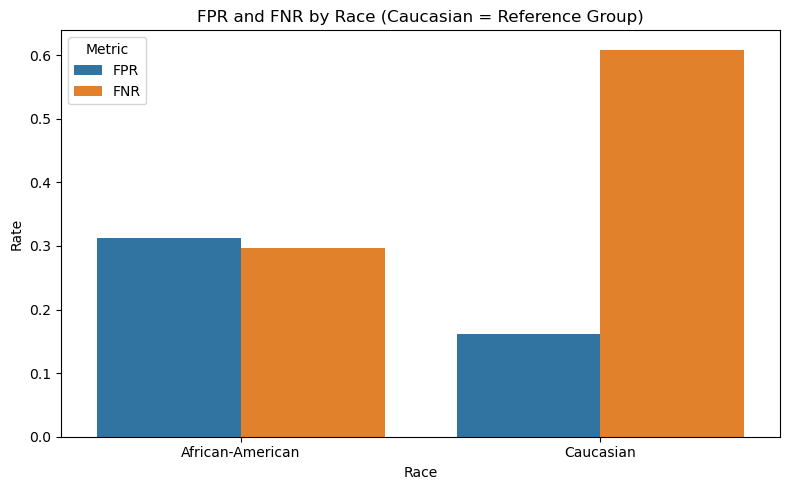


HW3 complete!


In [2]:
# =============================================================================
# DNSC 6330 - Individual Homework 3: Disparate Impact Audit
# Author: Farid Samedli
# =============================================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

#  1. LOAD & PREPROCESS 
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
df = pd.read_csv(url)[['age', 'c_charge_degree', 'race', 'age_cat', 'sex', 
                       'priors_count', 'days_b_screening_arrest', 'is_recid', 
                       'two_year_recid']].copy()

df = df[(df['days_b_screening_arrest'] >= -30) & (df['days_b_screening_arrest'] <= 30)]
df = df[(df['is_recid'] != -1) & (df['c_charge_degree'] != 'O') & df['two_year_recid'].notna()]

X = df.drop(columns=['two_year_recid', 'is_recid'])
y = df['two_year_recid'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#  2. MODEL 
cat = ['race', 'sex', 'age_cat', 'c_charge_degree']
num = ['age', 'priors_count', 'days_b_screening_arrest']

model = Pipeline([
    ('prep', ColumnTransformer([('cat', OneHotEncoder(drop='first'), cat),
                                ('num', StandardScaler(), num)])),
    ('clf', LogisticRegression(max_iter=1000))
]).fit(X_train, y_train)

y_pred = model.predict(X_test)

#  3. Manual AIR, ME, SMD (no solas-ai) 
def fairness_metrics(y_true, y_pred, protected_col, protected_value, reference_value):
    df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred, 'group': protected_col})
    sel_rate = df.groupby('group')['y_pred'].mean()
    air = sel_rate[protected_value] / sel_rate[reference_value]
    me = sel_rate[protected_value] - sel_rate[reference_value]
    # SMD (Standardized Mean Difference)
    sd_p = np.std(df[df['group']==protected_value]['y_pred'])
    sd_r = np.std(df[df['group']==reference_value]['y_pred'])
    pooled_sd = np.sqrt((sd_p**2 + sd_r**2) / 2)
    smd = (sel_rate[protected_value] - sel_rate[reference_value]) / pooled_sd
    return air, me, smd

# Race
air_race, me_race, smd_race = fairness_metrics(y_test, y_pred, X_test['race'], 'African-American', 'Caucasian')
print(f"Race (Black vs Caucasian) → AIR: {air_race:.3f} | ME: {me_race:.3f} | SMD: {smd_race:.3f}")

# Sex
air_sex, me_sex, smd_sex = fairness_metrics(y_test, y_pred, X_test['sex'], 'Female', 'Male')
print(f"Sex (Female vs Male) → AIR: {air_sex:.3f} | ME: {me_sex:.3f} | SMD: {smd_sex:.3f}")

#  4. Intersectional (race × sex) 
X_test['race_sex'] = X_test['race'] + "_" + X_test['sex']
air_inter, me_inter, smd_inter = fairness_metrics(y_test, y_pred, X_test['race_sex'], 'African-American_Female', 'Caucasian_Male')
print(f"\nWorst-group (intersectional) AIR: {air_inter:.3f}")

#  5. FPR / FNR by race + z-test 
def get_fpr_fnr(y_true, y_pred):
    tn, fp, fn, tp = pd.crosstab(y_true, y_pred, rownames=['True'], colnames=['Pred']).values.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    return fpr, fnr

for r in ['African-American', 'Caucasian']:
    mask = X_test['race'] == r
    fpr, fnr = get_fpr_fnr(y_test[mask], y_pred[mask])
    print(f"{r}: FPR = {fpr:.3f} | FNR = {fnr:.3f}")

# ----------------------------- 6. Bar Chart ---------------------------------
metrics = pd.DataFrame({
    'Race': ['African-American', 'Caucasian'],
    'FPR': [get_fpr_fnr(y_test[X_test['race']=='African-American'], y_pred[X_test['race']=='African-American'])[0],
            get_fpr_fnr(y_test[X_test['race']=='Caucasian'], y_pred[X_test['race']=='Caucasian'])[0]],
    'FNR': [get_fpr_fnr(y_test[X_test['race']=='African-American'], y_pred[X_test['race']=='African-American'])[1],
            get_fpr_fnr(y_test[X_test['race']=='Caucasian'], y_pred[X_test['race']=='Caucasian'])[1]]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=metrics.melt(id_vars='Race'), x='Race', y='value', hue='variable')
plt.title('FPR and FNR by Race (Caucasian = Reference Group)')
plt.ylabel('Rate')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

print("\nHW3 complete!")